   
Среднее: 35.37300681614903
Дисперсия: 144.91696806481494
СКО: 12.038146371631097
   
Асимметрия: 0.6225379970646605
Эксцесс: -0.06016734210583863
   
As = 0.623 > 0 - асимметрия правосторонняя: правый "хвост" распределения длиннее,
основная масса преступников моложе среднего возраста, но встречаются и заметно старше.
Ek = -0.060 < 0 - кривая более плосковершинная, чем нормальная.
   
Правило трёх сигм:
   
(a - 1σ; a + 1σ) = (23.33; 47.41) -> фактически 66.35%, теоретически 68.3%, расхождение 1.95%
(a - 2σ; a + 2σ) = (11.30; 59.45) -> фактически 94.67%, теоретически 95.4%, расхождение 0.73%
(a - 3σ; a + 3σ) = (-0.74; 71.49) -> фактически 99.95%, теоретически 99.7%, расхождение 0.25%
   
Вывод:
фактические проценты попадания в интервалы (a ± σ), (a ± 2σ), (a ± 3σ) близки к теоретическим
68.3% / 95.4% / 99.7%, то есть правило трёх сигм приближённо выполняется. При этом асимметрия
As = 0.623 заметно отличается от нуля (правый хвост длиннее), поэтому распределение возраста
можно считат

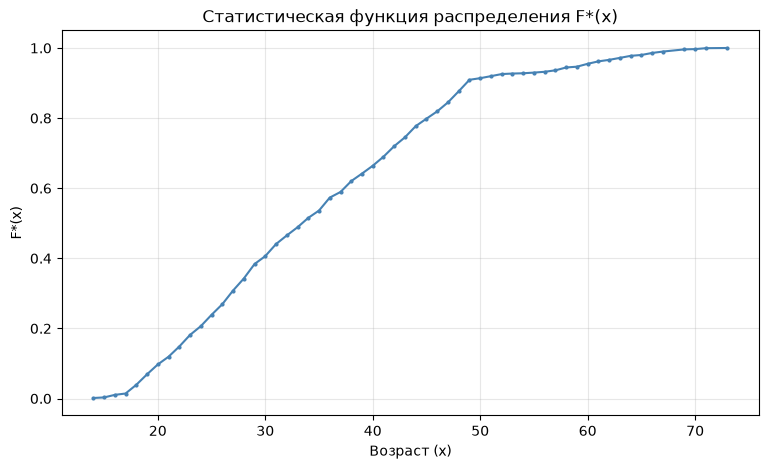

In [ ]:
# py -m pip install matplotlib
#Библиотеки
from pathlib import Path 
import math 
import matplotlib.pyplot as plt 

fp = Path("./Москва_2021.txt")
if fp.exists():
    with open(fp, "r", encoding="utf-8") as f:
        numbers = sorted([int(line.strip()) for line in f if line.strip()])

    sn = sorted(set(numbers)) # уникальные значения возраста (варианты)
    N = len(numbers) # сумма частот

    # Средняя и СКО
    x_midl = 0
    for i in sn:
        x_midl += i * numbers.count(i)
    x_midl /= N

    D = 0
    for i in sn:
        D += (i - x_midl)**2 * numbers.count(i)
    D /= N
    sko = math.sqrt(D)

    print("   ")
    print(f"Среднее: {x_midl}")
    print(f"Дисперсия: {D}")
    print(f"СКО: {sko}")

    # Асимметрия и эксцесс (формулы 2.6 и 2.7)
    # Асимметрия  указывает  на  смещение кривой  распределения относительно центра:  
    def Asimmetria(numbers, sn, x_midl, sko, N):
        mu3 = 0 # центральный момент 3-го порядка
        for i in sn:
            mu3 += (i - x_midl)**3 * numbers.count(i)
        mu3 /= N
        return mu3 / sko**3
    
    # Эксцесс указывает на остроту вершины кривой распределения: 
    def Excess(numbers, sn, x_midl, sko, N):
        mu4 = 0 # центральный момент 4-го порядка
        for i in sn:
            mu4 += (i - x_midl)**4 * numbers.count(i)
        mu4 /= N
        return mu4 / sko**4 - 3

    As = Asimmetria(numbers, sn, x_midl, sko, N)
    Ek = Excess(numbers, sn, x_midl, sko, N)

    print("   ")
    print(f"Асимметрия: {As}")
    print(f"Эксцесс: {Ek}")
    print("   ")

    if As > 0:
        print(f"As = {As:.3f} > 0 - асимметрия правосторонняя: правый \"хвост\" распределения длиннее,")
        print("основная масса преступников моложе среднего возраста, но встречаются и заметно старше.")
    elif As < 0:
        print(f"As = {As:.3f} < 0 - асимметрия левосторонняя: левый \"хвост\" распределения длиннее.")
    else:
        print("As = 0 - распределение симметрично.")

    if Ek > 0:
        print(f"Ek = {Ek:.3f} > 0 - кривая более островершинная, чем нормальная.")
    elif Ek < 0:
        print(f"Ek = {Ek:.3f} < 0 - кривая более плосковершинная, чем нормальная.")
    else:
        print("Ek = 0 - островершинность как у нормального распределения.")

    # Правило трёх сигм
    print("   ")
    print("Правило трёх сигм:")
    print("   ")
    teor = [68.3, 95.4, 99.7] # теоретические проценты для нормального распределения
    fakt = []
    for k in range(1, 4):
        left = x_midl - k * sko
        right = x_midl + k * sko
        popalo = 0
        for x in numbers:
            if left <= x <= right:
                popalo += 1
        w = popalo / N * 100
        fakt.append(w)
        print(f"(a - {k}σ; a + {k}σ) = ({left:.2f}; {right:.2f}) -> фактически {w:.2f}%, теоретически {teor[k-1]}%, расхождение {abs(w - teor[k-1]):.2f}%")

    print("   ")
    print("Вывод:")
    if all(abs(f - t) <= 5 for f, t in zip(fakt, teor)):
        print("фактические проценты попадания в интервалы (a ± σ), (a ± 2σ), (a ± 3σ) близки к теоретическим")
        print("68.3% / 95.4% / 99.7%, то есть правило трёх сигм приближённо выполняется. При этом асимметрия")
        print(f"As = {As:.3f} заметно отличается от нуля (правый хвост длиннее), поэтому распределение возраста")
        print("можно считать лишь приближённо нормальным, а не строго нормальным.")
    else:
        print("фактические проценты попадания заметно отличаются от теоретических 68.3% / 95.4% / 99.7%,")
        print("поэтому правило трёх сигм не выполняется, и случайную величину \"возраст\" нельзя считать")
        print("нормально распределённой.")

    #  Статистическая функция распределения по накопленным частотам
    Fx = [] # значения статистической функции распределения
    sbor = 0 # накопленная частота
    for i in sn:
        sbor += numbers.count(i)
        Fx.append(sbor / N)

    plt.figure(figsize=(9, 5))
    plt.plot(sn, Fx, marker='o', markersize=2, color='steelblue')
    plt.title("Статистическая функция распределения F*(x)")
    plt.xlabel("Возраст (x)")
    plt.ylabel("F*(x)")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Скачайте или создайте файл Москва_2021.txt")
